In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
from imports.check_data_utils import fetch_cauldron_image
# from imports.performance_utils import 

In [22]:
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt

In [23]:
from pathlib import Path 
import os
import math
import json
from typing import List, Dict
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

In [24]:

# EXPERIMENT_DIR_PATH = Path.cwd() / "experiment_data" / "runs"
# BEST_EXPERIMENT_DIR_NAME ="exp_20251127_132944"
# DATA_DIR_PATH = (EXPERIMENT_DIR_PATH / BEST_EXPERIMENT_DIR_NAME).resolve()
# os.listdir(DATA_DIR_PATH)

In [25]:
### Loading from Main Dataset

DATASET_ROOT_DIR = Path.cwd().parent.parent.parent / "dataset" / "final_dataset" /"router_final"
DATASET_ROOT_DIR

PosixPath('/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router/dataset/final_dataset/router_final')

In [26]:
EXPLORE_DATASET = "router_test_final"
DATA_PATH = (DATASET_ROOT_DIR / f"{EXPLORE_DATASET}.parquet").resolve()
DATA_PATH

PosixPath('/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router/dataset/final_dataset/router_final/router_test_final.parquet')

### Step-1: - Load the Dataset

In [27]:
# Load a local Parquet by pointing to a directory or specific file
ds = load_dataset("parquet", data_files=str(DATA_PATH))
ds

DatasetDict({
    train: Dataset({
        features: ['sample_id', 'image_path', 'image_bytes_hash', 'prompt_raw', 'img_width', 'img_height', 'img_aspect_ratio', 'txt_prompt_length_chars', 'txt_prompt_length_words', 'router_task', 'source_dataset', 'source_config', 'txt_question_type', 'txt_has_mc_options', 'ground_truth', 'ground_truth_type', 'router_best_model_id', 'router_best_model_name', 'router_chosen_perf', 'router_chosen_cost', 'router_soft_p_deepseek_ocr', 'router_soft_p_qwen2_5_vl_3b', 'router_soft_p_qwen2_5_vl_7b', 'router_soft_p_qwen3_vl_8b_thinking', 'router_soft_p_gemma_3_27b', 'deepseek_ocr__sample_score', 'deepseek_ocr__cost', 'deepseek_ocr__valid_mask', 'deepseek_ocr__is_correct', 'deepseek_ocr__score_f1', 'qwen2_5_vl_3b__sample_score', 'qwen2_5_vl_3b__cost', 'qwen2_5_vl_3b__valid_mask', 'qwen2_5_vl_3b__is_correct', 'qwen2_5_vl_3b__score_f1', 'qwen2_5_vl_7b__sample_score', 'qwen2_5_vl_7b__cost', 'qwen2_5_vl_7b__valid_mask', 'qwen2_5_vl_7b__is_correct', 'qwen2_5_vl_7b__

In [28]:
CURRENT_SAMPLE= ds['train'][5000]
CURRENT_SAMPLE

{'sample_id': 'infographic_vqa_00729_1ae73913b8e56c29',
 'image_path': None,
 'image_bytes_hash': '1ae73913b8e56c29',
 'prompt_raw': 'What percentage of large firms in UK experienced breaches on a monthly basis as of 8th May 2016?\nAnswer briefly.',
 'img_width': 827.0,
 'img_height': 1259.0,
 'img_aspect_ratio': 0.657,
 'txt_prompt_length_chars': 112.0,
 'txt_prompt_length_words': 20.0,
 'router_task': 'document_ocr',
 'source_dataset': 'cauldron_infographic_vqa',
 'source_config': 'infographic_vqa',
 'txt_question_type': 'what',
 'txt_has_mc_options': False,
 'ground_truth': '25%.',
 'ground_truth_type': 'exact',
 'router_best_model_id': 1,
 'router_best_model_name': 'qwen2_5_vl_3b',
 'router_chosen_perf': 0.9132896434515205,
 'router_chosen_cost': 0.10755840429019287,
 'router_soft_p_deepseek_ocr': 0.12819701986734608,
 'router_soft_p_qwen2_5_vl_3b': 0.2617583171255804,
 'router_soft_p_qwen2_5_vl_7b': 0.22317854094907735,
 'router_soft_p_qwen3_vl_8b_thinking': 0.14708519409738974,
 

In [29]:
# image, sample_dict = fetch_cauldron_image(
#     CURRENT_SAMPLE['source_config'],
#     CURRENT_SAMPLE['source_index'],
#     image_hash=CURRENT_SAMPLE['image_bytes_hash'],
# )
# display(image)


### Step-2: - Inspect Columns

In [30]:
df = ds['train'].to_pandas()

In [31]:
print("Number of columns:", len(df.columns))
print("\nFirst 40 columns:\n", df.columns[:40].tolist())

print("\nSubset of important global columns:")
global_cols = [
    "sample_id", "run_id", "timestamp_utc",
    "image_path", "image_bytes_hash",
    "prompt_raw", "source_dataset", "source_config",
    "router_task", "ground_truth", "ground_truth_type",
    "img_width", "img_height", "img_aspect_ratio",
    "txt_prompt_length_chars", "txt_prompt_length_words",
    "txt_question_type", "txt_has_mc_options",
    "subset_split"
]
for c in global_cols:
    if c in df.columns:
        print("-", c)
    else:
        print("-", c, "(MISSING)")

print("\nUnique subset_split values (if present):")
if "subset_split" in df.columns:
    print(df["subset_split"].value_counts(dropna=False))
else:
    print("No 'subset_split' column found.")


Number of columns: 50

First 40 columns:
 ['sample_id', 'image_path', 'image_bytes_hash', 'prompt_raw', 'img_width', 'img_height', 'img_aspect_ratio', 'txt_prompt_length_chars', 'txt_prompt_length_words', 'router_task', 'source_dataset', 'source_config', 'txt_question_type', 'txt_has_mc_options', 'ground_truth', 'ground_truth_type', 'router_best_model_id', 'router_best_model_name', 'router_chosen_perf', 'router_chosen_cost', 'router_soft_p_deepseek_ocr', 'router_soft_p_qwen2_5_vl_3b', 'router_soft_p_qwen2_5_vl_7b', 'router_soft_p_qwen3_vl_8b_thinking', 'router_soft_p_gemma_3_27b', 'deepseek_ocr__sample_score', 'deepseek_ocr__cost', 'deepseek_ocr__valid_mask', 'deepseek_ocr__is_correct', 'deepseek_ocr__score_f1', 'qwen2_5_vl_3b__sample_score', 'qwen2_5_vl_3b__cost', 'qwen2_5_vl_3b__valid_mask', 'qwen2_5_vl_3b__is_correct', 'qwen2_5_vl_3b__score_f1', 'qwen2_5_vl_7b__sample_score', 'qwen2_5_vl_7b__cost', 'qwen2_5_vl_7b__valid_mask', 'qwen2_5_vl_7b__is_correct', 'qwen2_5_vl_7b__score_f1']


### Define Model Specs (Prefix Mapping)

In [32]:
from imports.common_utils import return_model_specs
MODEL_SPECS = return_model_specs()

Configured models:
  id=0 name=deepseek_ocr prefix=deepseek_ocr__
  id=1 name=qwen2_5_vl_3b prefix=qwen2_5_vl_3b__
  id=2 name=qwen2_5_vl_7b prefix=qwen2_5_vl_7b__
  id=3 name=qwen3_vl_8b_thinking prefix=qwen3_vl_8b_thinking__
  id=4 name=gemma_3_27b prefix=gemma_3_27b__


### Sanity Check: One Row per Sample?

In [33]:
if df["sample_id"].is_unique:
    print("✅ sample_id is unique: one row per sample.")
else:
    print("⚠️ sample_id is NOT unique. You may have multiple runs per sample.")
    print("Value counts for repeated sample_ids:")
    print(df["sample_id"].value_counts().head())


✅ sample_id is unique: one row per sample.


### Check Model Availability & Ok Flag

In [34]:
for m in MODEL_SPECS:
    prefix = m["prefix"]
    ok_col = prefix + "ok"
    err_col = prefix + "error_message"
    
    if ok_col not in df.columns:
        print(f"⚠️ Missing column {ok_col}, skipping basic stats for model {m['name']}")
        continue
    
    ok_counts = df[ok_col].value_counts(dropna=False)
    print(f"\nModel: {m['name']}")
    print(f"  ok counts:\n{ok_counts}")
    
    if err_col in df.columns:
        n_errors = df[err_col].notna().sum()
        print(f"  rows with non-null error_message: {n_errors}")
    else:
        print(f"  no error_message column found for {m['name']}")


⚠️ Missing column deepseek_ocr__ok, skipping basic stats for model deepseek_ocr
⚠️ Missing column qwen2_5_vl_3b__ok, skipping basic stats for model qwen2_5_vl_3b
⚠️ Missing column qwen2_5_vl_7b__ok, skipping basic stats for model qwen2_5_vl_7b
⚠️ Missing column qwen3_vl_8b_thinking__ok, skipping basic stats for model qwen3_vl_8b_thinking
⚠️ Missing column gemma_3_27b__ok, skipping basic stats for model gemma_3_27b


#### Where did DeepSeek-OCR NOT run?

In [35]:
col = "deepseek_ocr__response_raw"

print("Column exists:", col in df.columns)
print("\nRaw value types and a few examples:")

print("dtype:", df[col].dtype)
print("\nvalue_counts (top 10):")
print(df[col].value_counts(dropna=False).head(10))


Column exists: False

Raw value types and a few examples:


KeyError: 'deepseek_ocr__response_raw'

In [ ]:
print("\nExamples where response_raw is NaN/None:")
display(df[df[col].isna()][["sample_id", "router_task", col]].head())


Examples where response_raw is NaN/None:


,sample_id,router_task,deepseek_ocr__response_raw


In [ ]:
print("\nExamples where response_raw is NOT NaN, but might be empty:")
display(
    df[
        df[col].notna() &
        (df[col].astype(str).str.strip() == "")
    ][["sample_id", "router_task", col]].head()
)


Examples where response_raw is NOT NaN, but might be empty:


,sample_id,router_task,deepseek_ocr__response_raw
0,ai2d_00000_45f9e7163ea99b4c,diagram_reasoning,
7,ai2d_00010_52deb93bedeb3cb7,diagram_reasoning,
9,ai2d_00012_ec5362254c87cf58,diagram_reasoning,
10,ai2d_00013_bcfca4647aef34dd,diagram_reasoning,
12,ai2d_00015_d4a695bc36f96c60,diagram_reasoning,


#### Which router_task values did NOT run DeepSeek-OCR?

In [ ]:
import pandas as pd
import numpy as np

def summarize_model_response_presence(
    df,
    model_name,
    prefix,
    router_task_col="router_task",
    require_ok=True,
):
    """
    For a given model block (identified by prefix), compute:
      - per-task counts of total, present, missing response_raw
      - lists of tasks where the model was never run / partially run / always run

    "present" means:
      - response_raw is not NaN
      - and not an empty / whitespace-only string
      - and (optionally) ok == True
    """
    col_resp = prefix + "response_raw"
    col_ok   = prefix + "ok"

    if col_resp not in df.columns:
        print(f"⚠️ Column {col_resp} not found for model {model_name}, skipping.")
        return None

    if router_task_col not in df.columns:
        raise KeyError(f"{router_task_col} column is missing in df!")

    # Base: non-null
    resp = df[col_resp]

    # Non-null & non-empty string
    non_null = resp.notna()
    non_empty = resp.astype(str).str.strip() != ""

    has_resp = non_null & non_empty

    # Optionally also require ok == True
    if require_ok and col_ok in df.columns:
        has_resp = has_resp & df[col_ok].fillna(False)

    # Per-task total and present
    total_per_task   = df.groupby(router_task_col)[col_resp].size()
    present_per_task = df[has_resp].groupby(router_task_col)[col_resp].size()

    # Align indices and fill missing with 0
    present_per_task = present_per_task.reindex(total_per_task.index, fill_value=0)
    missing_per_task = total_per_task - present_per_task

    summary = pd.DataFrame({
        "total": total_per_task,
        "present": present_per_task,
        "missing": missing_per_task,
    })

    # Derive task sets
    tasks_never   = summary[summary["present"] == 0].index.tolist()
    tasks_always  = summary[summary["missing"] == 0].index.tolist()
    tasks_partial = summary[(summary["present"] > 0) & (summary["missing"] > 0)].index.tolist()

    print(f"\n===== Model: {model_name} ({prefix}) =====")
    print("Overall:")
    print(f"  total rows:    {len(df)}")
    print(f"  with response: {has_resp.sum()}")
    print(f"  missing:       {(~has_resp).sum()}")

    print("\nPer-task summary (head):")
    display(summary.head(10))

    print("\nTasks where this model was NEVER run (response_raw always missing):")
    for t in tasks_never:
        print("  -", t)

    print("\nTasks where this model was run on ALL samples (no missing):")
    for t in tasks_always:
        print("  -", t)

    print("\nTasks where this model was run on SOME but not all samples:")
    for t in tasks_partial:
        print("  -", t)

    return {
        "summary": summary,
        "tasks_never": tasks_never,
        "tasks_always": tasks_always,
        "tasks_partial": tasks_partial,
    }


In [ ]:
model_presence_info = {}

for m in MODEL_SPECS:
    name   = m["name"]
    prefix = m["prefix"]
    info = summarize_model_response_presence(
        df,
        model_name=name,
        prefix=prefix,
        router_task_col="router_task",
        require_ok=True,   # change to False if you want to ignore ok
    )
    model_presence_info[name] = info



===== Model: deepseek_ocr (deepseek_ocr__) =====
Overall:
  total rows:    63963
  with response: 48299
  missing:       15664

Per-task summary (head):


,total,present,missing
router_task,,,
abstract_reasoning,1401,1350,51
chart_captioning,2795,2784,11
chart_reasoning,5491,4456,1035
code_generation,1352,1348,4
counting,1413,1413,0
dense_captioning,1410,1409,1
diagram_captioning,206,189,17
diagram_reasoning,1421,798,623
difference_detection,1398,1370,28



Tasks where this model was NEVER run (response_raw always missing):

Tasks where this model was run on ALL samples (no missing):
  - counting
  - medical_report
  - ui_captioning

Tasks where this model was run on SOME but not all samples:
  - abstract_reasoning
  - chart_captioning
  - chart_reasoning
  - code_generation
  - dense_captioning
  - diagram_captioning
  - diagram_reasoning
  - difference_detection
  - document_ocr
  - general_vqa
  - geometry_reasoning
  - handwriting_ocr
  - icon_reasoning
  - image_captioning
  - knowledge_vqa
  - map_reasoning
  - medical_vqa
  - meme_classification
  - rendered_text_ocr
  - scene_text_ocr
  - science_reasoning
  - spatial_reasoning
  - table_math
  - table_reasoning
  - textbook_qa
  - visual_mrc
  - web_understanding

===== Model: qwen2_5_vl_3b (qwen2_5_vl_3b__) =====
Overall:
  total rows:    63963
  with response: 63963
  missing:       0

Per-task summary (head):


,total,present,missing
router_task,,,
abstract_reasoning,1401,1401,0
chart_captioning,2795,2795,0
chart_reasoning,5491,5491,0
code_generation,1352,1352,0
counting,1413,1413,0
dense_captioning,1410,1410,0
diagram_captioning,206,206,0
diagram_reasoning,1421,1421,0
difference_detection,1398,1398,0



Tasks where this model was NEVER run (response_raw always missing):

Tasks where this model was run on ALL samples (no missing):
  - abstract_reasoning
  - chart_captioning
  - chart_reasoning
  - code_generation
  - counting
  - dense_captioning
  - diagram_captioning
  - diagram_reasoning
  - difference_detection
  - document_ocr
  - general_vqa
  - geometry_reasoning
  - handwriting_ocr
  - icon_reasoning
  - image_captioning
  - knowledge_vqa
  - map_reasoning
  - medical_report
  - medical_vqa
  - meme_classification
  - rendered_text_ocr
  - scene_text_ocr
  - science_reasoning
  - spatial_reasoning
  - table_math
  - table_reasoning
  - textbook_qa
  - ui_captioning
  - visual_mrc
  - web_understanding

Tasks where this model was run on SOME but not all samples:

===== Model: qwen2_5_vl_7b (qwen2_5_vl_7b__) =====
Overall:
  total rows:    63963
  with response: 63963
  missing:       0

Per-task summary (head):


...


Tasks where this model was NEVER run (response_raw always missing):

Tasks where this model was run on ALL samples (no missing):
  - abstract_reasoning
  - chart_captioning
  - chart_reasoning
  - code_generation
  - counting
  - dense_captioning
  - diagram_captioning
  - diagram_reasoning
  - difference_detection
  - document_ocr
  - general_vqa
  - geometry_reasoning
  - handwriting_ocr
  - icon_reasoning
  - image_captioning
  - knowledge_vqa
  - map_reasoning
  - medical_report
  - medical_vqa
  - meme_classification
  - rendered_text_ocr
  - scene_text_ocr
  - science_reasoning
  - spatial_reasoning
  - table_math
  - table_reasoning
  - textbook_qa
  - ui_captioning
  - visual_mrc
  - web_understanding

Tasks where this model was run on SOME but not all samples:

===== Model: qwen3_vl_8b_thinking (qwen3_vl_8b_thinking__) =====
Overall:
  total rows:    63963
  with response: 63963
  missing:       0

Per-task summary (head):


,total,present,missing
router_task,,,
abstract_reasoning,1401,1401,0
chart_captioning,2795,2795,0
chart_reasoning,5491,5491,0
code_generation,1352,1352,0
counting,1413,1413,0
dense_captioning,1410,1410,0
diagram_captioning,206,206,0
diagram_reasoning,1421,1421,0
difference_detection,1398,1398,0



Tasks where this model was NEVER run (response_raw always missing):

Tasks where this model was run on ALL samples (no missing):
  - abstract_reasoning
  - chart_captioning
  - chart_reasoning
  - code_generation
  - counting
  - dense_captioning
  - diagram_captioning
  - diagram_reasoning
  - difference_detection
  - document_ocr
  - general_vqa
  - geometry_reasoning
  - handwriting_ocr
  - icon_reasoning
  - image_captioning
  - knowledge_vqa
  - map_reasoning
  - medical_report
  - medical_vqa
  - meme_classification
  - rendered_text_ocr
  - scene_text_ocr
  - science_reasoning
  - spatial_reasoning
  - table_math
  - table_reasoning
  - textbook_qa
  - ui_captioning
  - visual_mrc
  - web_understanding

Tasks where this model was run on SOME but not all samples:

===== Model: gemma_3_27b (gemma_3_27b__) =====
Overall:
  total rows:    63963
  with response: 63963
  missing:       0

Per-task summary (head):


,total,present,missing
router_task,,,
abstract_reasoning,1401,1401,0
chart_captioning,2795,2795,0
chart_reasoning,5491,5491,0
code_generation,1352,1352,0
counting,1413,1413,0
dense_captioning,1410,1410,0
diagram_captioning,206,206,0
diagram_reasoning,1421,1421,0
difference_detection,1398,1398,0



Tasks where this model was NEVER run (response_raw always missing):

Tasks where this model was run on ALL samples (no missing):
  - abstract_reasoning
  - chart_captioning
  - chart_reasoning
  - code_generation
  - counting
  - dense_captioning
  - diagram_captioning
  - diagram_reasoning
  - difference_detection
  - document_ocr
  - general_vqa
  - geometry_reasoning
  - handwriting_ocr
  - icon_reasoning
  - image_captioning
  - knowledge_vqa
  - map_reasoning
  - medical_report
  - medical_vqa
  - meme_classification
  - rendered_text_ocr
  - scene_text_ocr
  - science_reasoning
  - spatial_reasoning
  - table_math
  - table_reasoning
  - textbook_qa
  - ui_captioning
  - visual_mrc
  - web_understanding

Tasks where this model was run on SOME but not all samples:


<Figure size 1000x400 with 0 Axes>

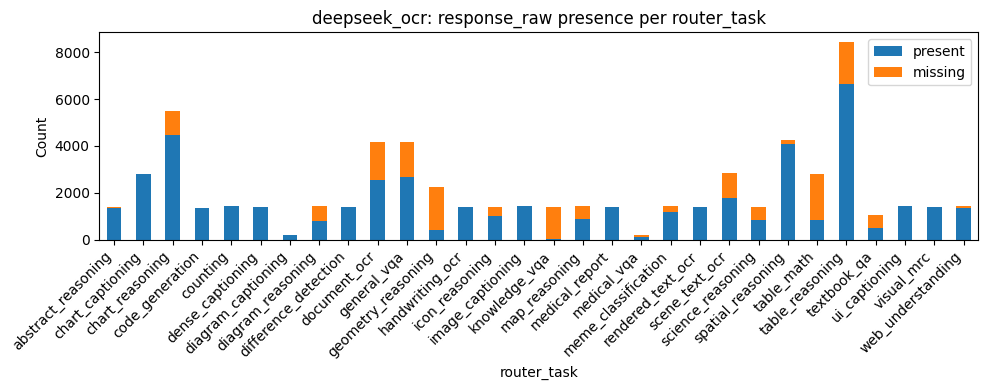

<Figure size 1000x400 with 0 Axes>

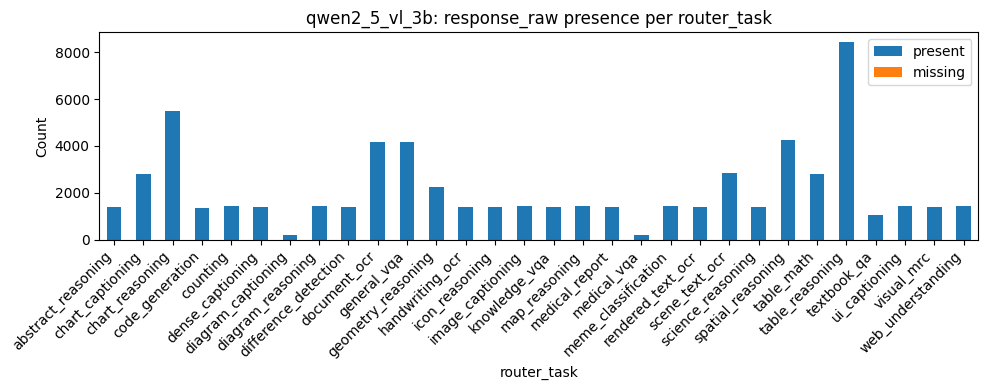

<Figure size 1000x400 with 0 Axes>

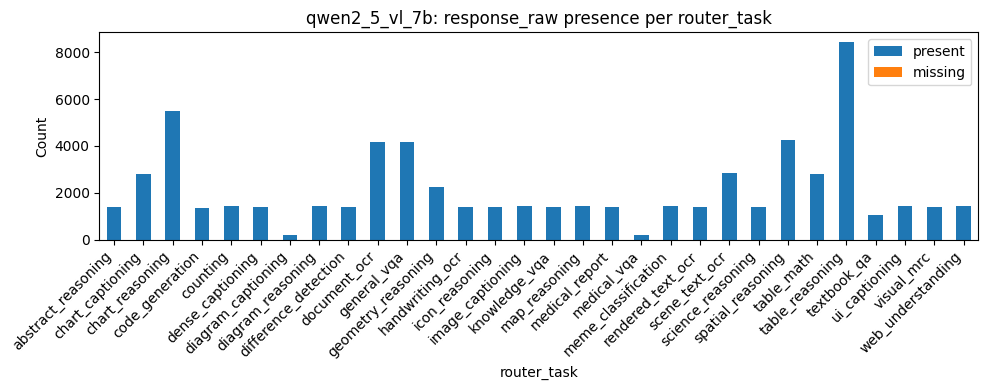

<Figure size 1000x400 with 0 Axes>

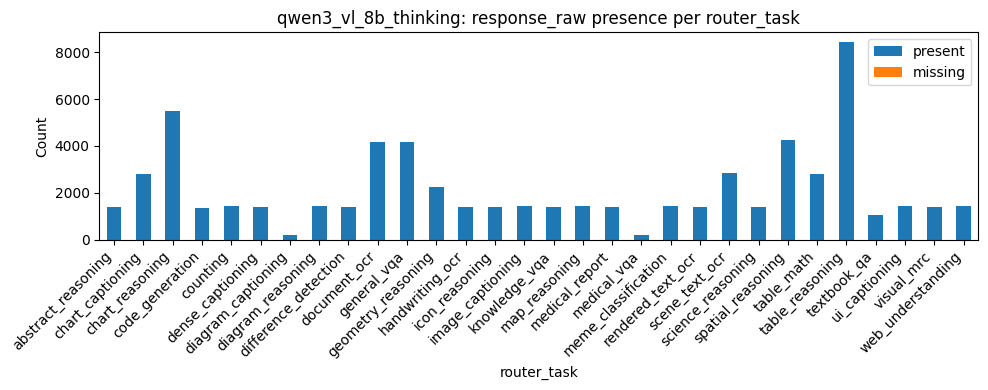

<Figure size 1000x400 with 0 Axes>

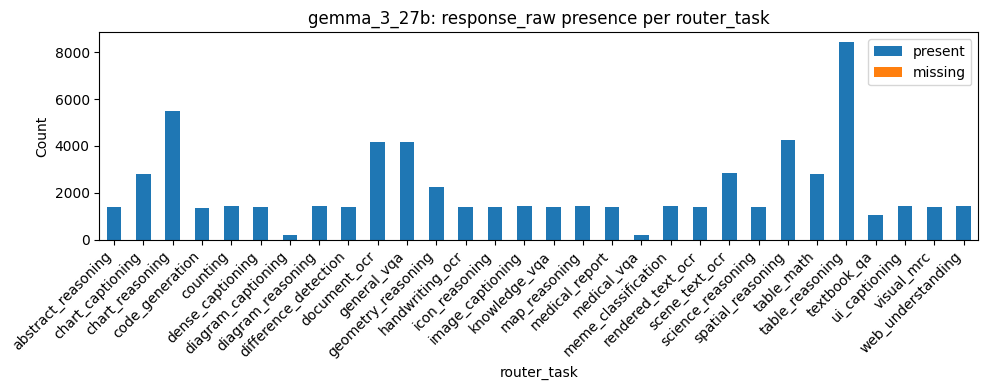

In [ ]:
import matplotlib.pyplot as plt

for m in MODEL_SPECS:
    name = m["name"]
    info = model_presence_info.get(name)
    if info is None:
        continue
    
    summary = info["summary"]
    
    plt.figure(figsize=(10, 4))
    summary[["present", "missing"]].plot(
        kind="bar",
        stacked=True,
        figsize=(10, 4),
        title=f"{name}: response_raw presence per router_task"
    )
    plt.xlabel("router_task")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


In [ ]:
print(df.shape)
df.head(2)
df.info()


(63963, 223)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63963 entries, 0 to 63962
Columns: 223 entries, sample_id to subset_split
dtypes: bool(16), float64(96), int64(1), object(110)
memory usage: 102.0+ MB


In [ ]:
print("subset_split:", df["subset_split"].value_counts(dropna=False))
print("router_task:", df["router_task"].value_counts(dropna=False).head(20))
print("source_dataset:", df["source_dataset"].value_counts(dropna=False))
print("source_config:", df["source_config"].value_counts(dropna=False))

df["txt_has_mc_options"].value_counts(dropna=False)
df["txt_question_type"].value_counts(dropna=False)


subset_split: subset_split
train    63963
Name: count, dtype: int64
router_task: router_task
table_reasoning        8434
chart_reasoning        5491
spatial_reasoning      4254
general_vqa            4170
document_ocr           4148
scene_text_ocr         2833
table_math             2813
chart_captioning       2795
geometry_reasoning     2256
image_captioning       1439
web_understanding      1431
map_reasoning          1430
diagram_reasoning      1421
ui_captioning          1415
meme_classification    1415
counting               1413
dense_captioning       1410
science_reasoning      1408
knowledge_vqa          1405
handwriting_ocr        1403
Name: count, dtype: int64
source_dataset: source_dataset
cauldron_textcaps                 1439
cauldron_websight                 1431
cauldron_vsr                      1431
cauldron_mapqa                    1430
cauldron_nlvr2                    1427
cauldron_textvqa                  1424
cauldron_ai2d                     1421
cauldron_robut_sq

txt_question_type
None      30033
what      14763
yes_no     7334
how        5821
which      2761
who        2297
when        410
where       366
why         178
Name: count, dtype: int64

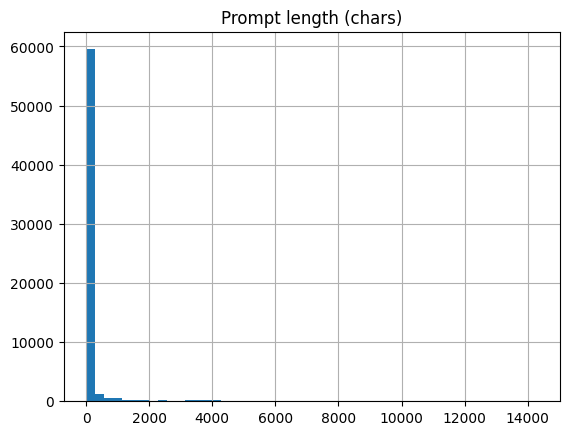

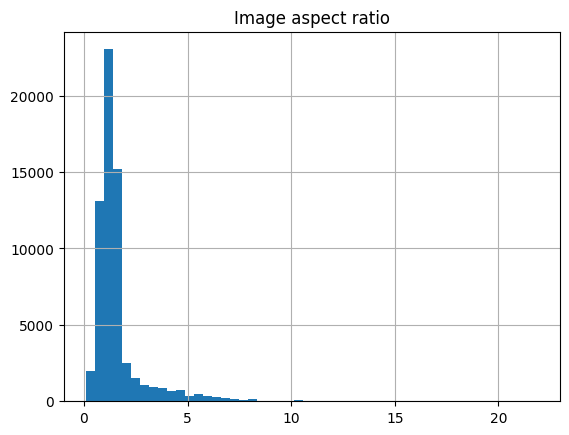

In [ ]:
df["txt_prompt_length_chars"].hist(bins=50)
plt.title("Prompt length (chars)")
plt.show()

df["img_aspect_ratio"].hist(bins=50)
plt.title("Image aspect ratio")
plt.show()


In [ ]:
MODEL_SPECS = [
    {"name": "deepseek_ocr",         "prefix": "deepseek_ocr__"},
    {"name": "qwen2_5_vl_3b",       "prefix": "qwen2_5_vl_3b__"},
    {"name": "qwen2_5_vl_7b",       "prefix": "qwen2_5_vl_7b__"},
    {"name": "qwen3_vl_8b_thinking","prefix": "qwen3_vl_8b_thinking__"},
    {"name": "gemma_3_27b",         "prefix": "gemma_3_27b__"},
]


In [ ]:
def model_eda(df, name, prefix):
    col_resp   = prefix + "response_raw"
    col_ok     = prefix + "ok"
    col_err    = prefix + "error_message"
    col_corr   = prefix + "is_correct"
    col_lat    = prefix + "latency_ms"
    col_cost   = prefix + "estimated_cost_usd"
    col_tokens = prefix + "total_tokens"

    print(f"\n===== {name} ({prefix}) =====")

    # 1) Response presence
    resp = df[col_resp]
    non_null  = resp.notna()
    non_empty = resp.astype(str).str.strip() != ""
    has_resp  = non_null & non_empty

    print("Total rows:", len(df))
    print("  has_resp (non-null & non-empty):", has_resp.sum())
    print("  resp is NaN:", (~non_null).sum())
    print("  resp is empty string:", (non_null & ~non_empty).sum())

    # 2) Check cases like your example: empty string but still tokens/latency
    weird_empty = df[non_null & ~non_empty & df[prefix + "total_tokens"].fillna(0) > 0]
    print("  Empty response but tokens>0 count:", len(weird_empty))

    # 3) ok / error
    if col_ok in df.columns:
        print("ok value_counts:\n", df[col_ok].value_counts(dropna=False))
    if col_err in df.columns:
        print("non-null error_message:", df[col_err].notna().sum())

    # 4) Accuracy-ish and latency/cost
    if col_corr in df.columns:
        print("is_correct value_counts:\n", df[col_corr].value_counts(dropna=False))

    if col_lat in df.columns:
        print("latency_ms describe:\n", df[col_lat].describe())

    if col_cost in df.columns:
        print("estimated_cost_usd describe:\n", df[col_cost].describe())

    if col_tokens in df.columns:
        print("total_tokens describe:\n", df[col_tokens].describe())

for m in MODEL_SPECS:
    model_eda(df, m["name"], m["prefix"])



===== deepseek_ocr (deepseek_ocr__) =====
Total rows: 63963
  has_resp (non-null & non-empty): 48299
  resp is NaN: 0
  resp is empty string: 15664
  Empty response but tokens>0 count: 15664
ok value_counts:
 deepseek_ocr__ok
True    63963
Name: count, dtype: int64
non-null error_message: 0
is_correct value_counts:
 deepseek_ocr__is_correct
False    49848
True     14115
Name: count, dtype: int64
latency_ms describe:
 count    63963.000000
mean       879.121161
std        679.894236
min         84.686995
25%        380.573511
50%        733.348846
75%       1200.444460
max      20932.207108
Name: deepseek_ocr__latency_ms, dtype: float64
estimated_cost_usd describe:
 count    63963.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: deepseek_ocr__estimated_cost_usd, dtype: float64
total_tokens describe:
 count    63963.000000
mean       649.415131
std        335.043627
min        283.000000
25%        313.000000


In [ ]:
def model_task_coverage(df, name, prefix):
    col_resp = prefix + "response_raw"
    resp = df[col_resp]

    non_null  = resp.notna()
    non_empty = resp.astype(str).str.strip() != ""
    has_resp  = non_null & non_empty

    task = df["router_task"]

    total_per_task   = task.value_counts().sort_index()
    present_per_task = task[has_resp].value_counts().reindex(total_per_task.index, fill_value=0)
    missing_per_task = total_per_task - present_per_task

    coverage = pd.DataFrame({
        "total": total_per_task,
        "present": present_per_task,
        "missing": missing_per_task,
        "present_frac": present_per_task / total_per_task,
    })

    print(f"\n=== Coverage for {name} by router_task ===")
    display(coverage)

for m in MODEL_SPECS:
    model_task_coverage(df, m["name"], m["prefix"])



=== Coverage for deepseek_ocr by router_task ===


,total,present,missing,present_frac
router_task,,,,
abstract_reasoning,1401,1350,51,0.963597
chart_captioning,2795,2784,11,0.996064
chart_reasoning,5491,4456,1035,0.811510
code_generation,1352,1348,4,0.997041
counting,1413,1413,0,1.000000
dense_captioning,1410,1409,1,0.999291
diagram_captioning,206,189,17,0.917476
diagram_reasoning,1421,798,623,0.561576
difference_detection,1398,1370,28,0.979971



=== Coverage for qwen2_5_vl_3b by router_task ===


,total,present,missing,present_frac
router_task,,,,
abstract_reasoning,1401,1401,0,1.0
chart_captioning,2795,2795,0,1.0
chart_reasoning,5491,5491,0,1.0
code_generation,1352,1352,0,1.0
counting,1413,1413,0,1.0
dense_captioning,1410,1410,0,1.0
diagram_captioning,206,206,0,1.0
diagram_reasoning,1421,1421,0,1.0
difference_detection,1398,1398,0,1.0



=== Coverage for qwen2_5_vl_7b by router_task ===


,total,present,missing,present_frac
router_task,,,,
abstract_reasoning,1401,1401,0,1.0
chart_captioning,2795,2795,0,1.0
chart_reasoning,5491,5491,0,1.0
code_generation,1352,1352,0,1.0
counting,1413,1413,0,1.0
dense_captioning,1410,1410,0,1.0
diagram_captioning,206,206,0,1.0
diagram_reasoning,1421,1421,0,1.0
difference_detection,1398,1398,0,1.0



=== Coverage for qwen3_vl_8b_thinking by router_task ===


,total,present,missing,present_frac
router_task,,,,
abstract_reasoning,1401,1401,0,1.0
chart_captioning,2795,2795,0,1.0
chart_reasoning,5491,5491,0,1.0
code_generation,1352,1352,0,1.0
counting,1413,1413,0,1.0
dense_captioning,1410,1410,0,1.0
diagram_captioning,206,206,0,1.0
diagram_reasoning,1421,1421,0,1.0
difference_detection,1398,1398,0,1.0



=== Coverage for gemma_3_27b by router_task ===


,total,present,missing,present_frac
router_task,,,,
abstract_reasoning,1401,1401,0,1.0
chart_captioning,2795,2795,0,1.0
chart_reasoning,5491,5491,0,1.0
code_generation,1352,1352,0,1.0
counting,1413,1413,0,1.0
dense_captioning,1410,1410,0,1.0
diagram_captioning,206,206,0,1.0
diagram_reasoning,1421,1421,0,1.0
difference_detection,1398,1398,0,1.0


In [ ]:
def model_task_coverage(df, name, prefix):
    col_resp = prefix + "response_raw"
    resp = df[col_resp]

    non_null  = resp.notna()
    non_empty = resp.astype(str).str.strip() != ""
    has_resp  = non_null & non_empty

    task = df["router_task"]

    total_per_task   = task.value_counts().sort_index()
    present_per_task = task[has_resp].value_counts().reindex(total_per_task.index, fill_value=0)
    missing_per_task = total_per_task - present_per_task

    coverage = pd.DataFrame({
        "total": total_per_task,
        "present": present_per_task,
        "missing": missing_per_task,
        "present_frac": present_per_task / total_per_task,
    })

    print(f"\n=== Coverage for {name} by router_task ===")
    display(coverage)

for m in MODEL_SPECS:
    model_task_coverage(df, m["name"], m["prefix"])



=== Coverage for deepseek_ocr by router_task ===


,total,present,missing,present_frac
router_task,,,,
abstract_reasoning,1401,1350,51,0.963597
chart_captioning,2795,2784,11,0.996064
chart_reasoning,5491,4456,1035,0.811510
code_generation,1352,1348,4,0.997041
counting,1413,1413,0,1.000000
dense_captioning,1410,1409,1,0.999291
diagram_captioning,206,189,17,0.917476
diagram_reasoning,1421,798,623,0.561576
difference_detection,1398,1370,28,0.979971



=== Coverage for qwen2_5_vl_3b by router_task ===


,total,present,missing,present_frac
router_task,,,,
abstract_reasoning,1401,1401,0,1.0
chart_captioning,2795,2795,0,1.0
chart_reasoning,5491,5491,0,1.0
code_generation,1352,1352,0,1.0
counting,1413,1413,0,1.0
dense_captioning,1410,1410,0,1.0
diagram_captioning,206,206,0,1.0
diagram_reasoning,1421,1421,0,1.0
difference_detection,1398,1398,0,1.0



=== Coverage for qwen2_5_vl_7b by router_task ===


,total,present,missing,present_frac
router_task,,,,
abstract_reasoning,1401,1401,0,1.0
chart_captioning,2795,2795,0,1.0
chart_reasoning,5491,5491,0,1.0
code_generation,1352,1352,0,1.0
counting,1413,1413,0,1.0
dense_captioning,1410,1410,0,1.0
diagram_captioning,206,206,0,1.0
diagram_reasoning,1421,1421,0,1.0
difference_detection,1398,1398,0,1.0



=== Coverage for qwen3_vl_8b_thinking by router_task ===


,total,present,missing,present_frac
router_task,,,,
abstract_reasoning,1401,1401,0,1.0
chart_captioning,2795,2795,0,1.0
chart_reasoning,5491,5491,0,1.0
code_generation,1352,1352,0,1.0
counting,1413,1413,0,1.0
dense_captioning,1410,1410,0,1.0
diagram_captioning,206,206,0,1.0
diagram_reasoning,1421,1421,0,1.0
difference_detection,1398,1398,0,1.0



=== Coverage for gemma_3_27b by router_task ===


,total,present,missing,present_frac
router_task,,,,
abstract_reasoning,1401,1401,0,1.0
chart_captioning,2795,2795,0,1.0
chart_reasoning,5491,5491,0,1.0
code_generation,1352,1352,0,1.0
counting,1413,1413,0,1.0
dense_captioning,1410,1410,0,1.0
diagram_captioning,206,206,0,1.0
diagram_reasoning,1421,1421,0,1.0
difference_detection,1398,1398,0,1.0


In [ ]:
score_cols = {m["name"]: m["prefix"] + "score_f1" for m in MODEL_SPECS}

score_df = pd.DataFrame({
    name: df[col].fillna(0.0).astype(float)
    for name, col in score_cols.items()
})

best_model_by_f1 = score_df.idxmax(axis=1)
df["eda_best_model_f1"] = best_model_by_f1

print("Best model by score_f1 (overall):")
print(df["eda_best_model_f1"].value_counts())


Best model by score_f1 (overall):
eda_best_model_f1
qwen2_5_vl_3b           38117
deepseek_ocr            12495
qwen2_5_vl_7b            8723
gemma_3_27b              2611
qwen3_vl_8b_thinking     2017
Name: count, dtype: int64


In [ ]:
for m in MODEL_SPECS:
    name   = m["name"]
    prefix = m["prefix"]
    acc_col  = prefix + "is_correct"
    cost_col = prefix + "estimated_cost_usd"
    lat_col  = prefix + "latency_ms"

    sub = df[[acc_col, cost_col, lat_col]].copy()
    sub = sub[sub[acc_col].notna()]

    print(f"\n=== {name} ===")
    print("Accuracy:", sub[acc_col].mean())
    print("Avg cost:", (sub[cost_col].mean()))
    print("Avg latency_ms:", sub[lat_col].mean())



=== deepseek_ocr ===
Accuracy: 0.22067445241780403
Avg cost: 0.0
Avg latency_ms: 879.1211613153123

=== qwen2_5_vl_3b ===
Accuracy: 0.6072104185232088
Avg cost: 0.0
Avg latency_ms: 993.0918620238542

=== qwen2_5_vl_7b ===
Accuracy: 0.5962196895079969
Avg cost: 0.0
Avg latency_ms: 1454.957180394596

=== qwen3_vl_8b_thinking ===
Accuracy: 0.45981270421962694
Avg cost: 0.0
Avg latency_ms: 3234.4181765449625

=== gemma_3_27b ===
Accuracy: 0.4006066006910245
Avg cost: 0.0
Avg latency_ms: 2714.075618771062


In [ ]:
def classify_response_state(df, prefix):
    resp = df[prefix + "response_raw"]
    tokens = df[prefix + "total_tokens"].fillna(0)
    lat    = df[prefix + "latency_ms"].fillna(0)

    is_nan      = resp.isna()
    is_empty    = resp.astype(str).str.strip() == ""
    has_tokens  = tokens > 0
    has_latency = lat > 0

    # Simple heuristics
    fully_missing = is_nan & ~has_tokens & ~has_latency
    ran_empty     = (~is_nan) & is_empty & (has_tokens | has_latency)
    ran_normal    = (~is_nan) & (~is_empty) & (has_tokens | has_latency)

    return fully_missing, ran_empty, ran_normal

for m in MODEL_SPECS:
    nm = m["name"]
    prefix = m["prefix"]
    fm, re, rn = classify_response_state(df, prefix)
    print(f"\n=== {nm} ===")
    print("Fully missing:", fm.sum())
    print("Ran but empty:", re.sum())
    print("Ran normal:   ", rn.sum())



=== deepseek_ocr ===
Fully missing: 0
Ran but empty: 15664
Ran normal:    48299

=== qwen2_5_vl_3b ===
Fully missing: 0
Ran but empty: 0
Ran normal:    63963

=== qwen2_5_vl_7b ===
Fully missing: 0
Ran but empty: 0
Ran normal:    63963

=== qwen3_vl_8b_thinking ===
Fully missing: 0
Ran but empty: 0
Ran normal:    63963

=== gemma_3_27b ===
Fully missing: 0
Ran but empty: 0
Ran normal:    63963


### Glider Sanity Check: Are CoT Models Penalized?


In [ ]:
# 1) Compare Glider score distributions across models
print("Mean / median Glider score by model:")
for m in MODEL_SPECS:
    name = m["name"]
    col = f"{name}__glider_score"
    if col not in df.columns:
        continue
    g = df[col].dropna()
    print(f"{name:25s} → mean={g.mean():.3f}, median={g.median():.3f}, n={len(g)}")


Mean / median Glider score by model:
deepseek_ocr              → mean=1.810, median=0.000, n=63963
qwen2_5_vl_3b             → mean=3.582, median=4.000, n=63963
qwen2_5_vl_7b             → mean=3.849, median=4.000, n=63963
qwen3_vl_8b_thinking      → mean=3.286, median=4.000, n=63963
gemma_3_27b               → mean=3.252, median=4.000, n=63963


In [ ]:

# 2) For the thinking model: correlation with response length
think_name = "qwen3_vl_8b_thinking"
g_col      = f"{think_name}__glider_score"
len_col    = f"{think_name}__response_length_tokens"

if g_col in df.columns and len_col in df.columns:
    g    = df[g_col]
    toks = df[len_col]

    df_tmp = pd.DataFrame({"glider": g, "tokens": toks}).dropna()
    corr = df_tmp["glider"].corr(df_tmp["tokens"])
    print(f"\n[{think_name}] Corr(response_length_tokens, glider_score) = {corr:.3f}")

    # Bin by length to see trend
    bins = [0, 50, 100, 200, 400, 800, 2000]
    df_tmp["len_bin"] = pd.cut(df_tmp["tokens"], bins=bins)
    print("\nMean Glider score by response length bin:")
    display(df_tmp.groupby("len_bin")["glider"].mean())




[qwen3_vl_8b_thinking] Corr(response_length_tokens, glider_score) = -0.340

Mean Glider score by response length bin:


/var/folders/l8/nbcrmtqs2838_6yr979chd1m0000gn/T/ipykernel_46456/578030712.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df_tmp.groupby("len_bin")["glider"].mean())


len_bin
(0, 50]        3.988057
(50, 100]      3.797414
(100, 200]     3.704218
(200, 400]     3.806279
(400, 800]     2.586427
(800, 2000]         NaN
Name: glider, dtype: float64

In [ ]:
# 3) Check </think> tag correlation
resp_col = f"{think_name}__response_raw"
if resp_col in df.columns and g_col in df.columns:
    resp = df[resp_col].astype(str)
    has_think = resp.str.contains("</think>", regex=False)

    print("\nGlider scores with vs without </think>:")
    display(
        df.groupby(has_think)[g_col].agg(["mean", "median", "count"]).rename_axis("has_think")
    )



Glider scores with vs without </think>:


,mean,median,count
has_think,,,
False,2.166243,4.0,20085
True,3.798623,4.0,43878


### Select Final Columns for Router Training

In [ ]:
# input_cols = [
#     "sample_id",
#     "router_image_path",
#     "router_text_input",
#     "router_task",
#     "source_dataset",
#     "source_config",
#     "txt_question_type",
#     "img_width",
#     "img_height",
#     "img_aspect_ratio",
#     "txt_prompt_length_chars",
#     "txt_prompt_length_words",
#     "ground_truth",
#     "ground_truth_type",
#     "subset_split",
# ]

# label_cols = [
#     "router_best_model_id",
#     "router_best_model_name",
# ]

# perf_cost_utility_cols = []
# for m in MODEL_SPECS:
#     perf_cost_utility_cols.extend([
#         f"{m['name']}__perf",
#         f"{m['name']}__cost",
#         f"{m['name']}__utility",
#         f"{m['name']}__valid_mask",
#     ])

# soft_prob_cols = [c for c in df_proc.columns if c.startswith("router_soft_p_")]

# final_cols = [c for c in input_cols if c in df_proc.columns] + label_cols + perf_cost_utility_cols + soft_prob_cols

# router_df = df_proc[final_cols].copy()

# print("Final router_df shape:", router_df.shape)
# router_df.head(3)


### Save Processed Router Dataset

In [ ]:
# OUT_PATH = "../data/router_dataset_processed.parquet"  # change if needed
# router_df.to_parquet(OUT_PATH, index=False)
# print("Saved processed router dataset to:", OUT_PATH)


In [ ]:
# print("=== Summary ===")
# print("Total samples:", len(router_df))

# print("\nBest model distribution:")
# print(router_df["router_best_model_name"].value_counts())

# if "subset_split" in router_df.columns:
#     print("\nsubset_split distribution:")
#     print(router_df["subset_split"].value_counts())
